In [1]:
!pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 870.5/870.5 kB 21.2 MB/s eta 0:00:00


In [2]:
!git clone https://github.com/ultralytics/YOLOv8
!cd YOLOv8 && pip install -r requirements.txt

Cloning into 'YOLOv8'...
fatal: could not read Username for 'https://github.com': No such device or address
/bin/bash: line 1: cd: YOLOv8: No such file or directory


In [3]:
from ultralytics import YOLO

from IPython.display import display, Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Lane Detection

In [4]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="EL2Z29J4BkOtL9xBSdND")
project = rf.workspace("lane-detection-2ja6y").project("lane-detection-for-yolov8")
version = project.version(6)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.3 MB/s eta 0:00:00
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Lane-Detection-for-YOLOv8-6 in yolov8:: 100%|██████████| 3028/3028 [00:02<00:00, 1439.53it/s]


# Lane segmentation

In [5]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="EL2Z29J4BkOtL9xBSdND")
project = rf.workspace("rdl").project("lanedetector-zsct6")
version = project.version(8)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to lanedetector-8 in yolov8:: 100%|██████████| 12704/12704 [00:06<00:00, 2022.04it/s]


In [ ]:
!yolo task=segment mode=train model=yolov8n-seg.pt data='/content/lanedetector-8/data.yaml' epochs=25 imgsz=640

100% 6.74M/6.74M [00:00<00:00, 100MB/s]
Ultralytics 8.3.13 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=segment, mode=train, model=yolov8n-seg.pt, data=/content/lanedetector-8/data.yaml, epochs=25, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop

In [9]:
model=YOLO('/content/runs/segment/train/weights/best.pt')

FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/segment/train/weights/best.pt'

In [ ]:
model.save('/content/lane.pt')

In [6]:
lane_model=YOLO('/content/lane.pt')

# Detect Lane in video

In [7]:
import cv2
import numpy as np
from ultralytics import YOLO
from google.colab.patches import cv2_imshow


# Input video file
input_video_path = '/content/challenge.mp4'  # Replace with your input video file path
output_video_path = '/content/output_video_lane_overlaid.mp4'  # Path to save the output video

# Initialize video capture
cap = cv2.VideoCapture(input_video_path)

# Get video properties
fps = cap.get(cv2.CAP_PROP_FPS)  # Frames per second
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))  # Frame width
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))  # Frame height

# Initialize video writer to save output
fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Codec for mp4
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

# Process the video
while True:
    ret, frame = cap.read()
    if not ret:
        break  # Exit if the frame is not captured correctly

    # Perform lane segmentation
    results = lane_model(frame)  # Get segmentation results

    # Create a mask for the lane lines
    lane_mask = np.zeros((height, width), dtype=np.uint8)

    # Extract lane line masks
    for result in results:
        if result.masks is not None:
            for mask_data in result.masks.data:  # Loop through masks
                # Move the tensor to the CPU before converting to NumPy
                mask_image = mask_data.cpu().numpy().astype(np.uint8)  # Convert to numpy array

                # Resize the mask to match the frame dimensions
                mask_image = cv2.resize(mask_image, (width, height))

                # Assuming lane line class index is known (e.g., index 0 for lane line)
                lane_mask = cv2.bitwise_or(lane_mask, mask_image)

    # Create a colored overlay for lane lines
    lane_overlay = np.zeros_like(frame)
    lane_overlay[:, :, 0] = 255  # Set the overlay color (e.g., blue)

    # Apply the mask to the overlay
    lane_overlay = cv2.bitwise_and(lane_overlay, lane_overlay, mask=lane_mask)

    # Blend the original frame with the lane overlay
    output_frame = cv2.addWeighted(frame, 1, lane_overlay, 0.5, 0)

    # Write the processed frame to the output video
    out.write(output_frame)

    # Optional: Display the frame (for testing purposes)
    # cv2_imshow(output_frame)

# Release resources
cap.release()
out.release()
cv2.destroyAllWindows()


0: 384x640 4 LaneLines, 92.7ms
Speed: 18.3ms preprocess, 92.7ms inference, 1183.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 LaneLines, 8.3ms
Speed: 2.8ms preprocess, 8.3ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 LaneLines, 7.5ms
Speed: 3.0ms preprocess, 7.5ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 LaneLines, 7.3ms
Speed: 2.6ms preprocess, 7.3ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 LaneLines, 7.8ms
Speed: 2.6ms preprocess, 7.8ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 LaneLines, 9.1ms
Speed: 2.6ms preprocess, 9.1ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 LaneLines, 8.0ms
Speed: 2.6ms preprocess, 8.0ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 LaneLines, 7.8ms
Speed: 3.0ms preprocess, 7.8ms inference, 1.7ms postprocess per image at s

# vehicle Detection

In [8]:
from ultralytics import YOLO
from IPython.display import display, Image
import pandas as pd
import cv2
from google.colab.patches import cv2_imshow

In [ ]:
!yolo task=detect mode=train model=yolov8n.pt data='/content/drive/MyDrive/we/Vehicle_Detection_Image_Dataset/data.yaml' epochs=25 imgsz=640

100% 6.25M/6.25M [00:00<00:00, 113MB/s]
Ultralytics 8.3.13 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/drive/MyDrive/we/Vehicle_Detection_Image_Dataset/data.yaml, epochs=25, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=Fals

In [ ]:
model1=YOLO('/content/runs/detect/train/weights/last.pt')

In [ ]:
model1.save('/content/vehicle.pt')

In [9]:
vehicle_model=YOLO('/content/vehicle.pt')

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



image 1/1 /content/drive/MyDrive/Vehicle_Detection_Image_Dataset/train/images/10_mp4-10_jpg.rf.b87509668caff369c5501325477e6d9a.jpg: 640x640 22 Vehicles, 7.2ms
Speed: 1.7ms preprocess, 7.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


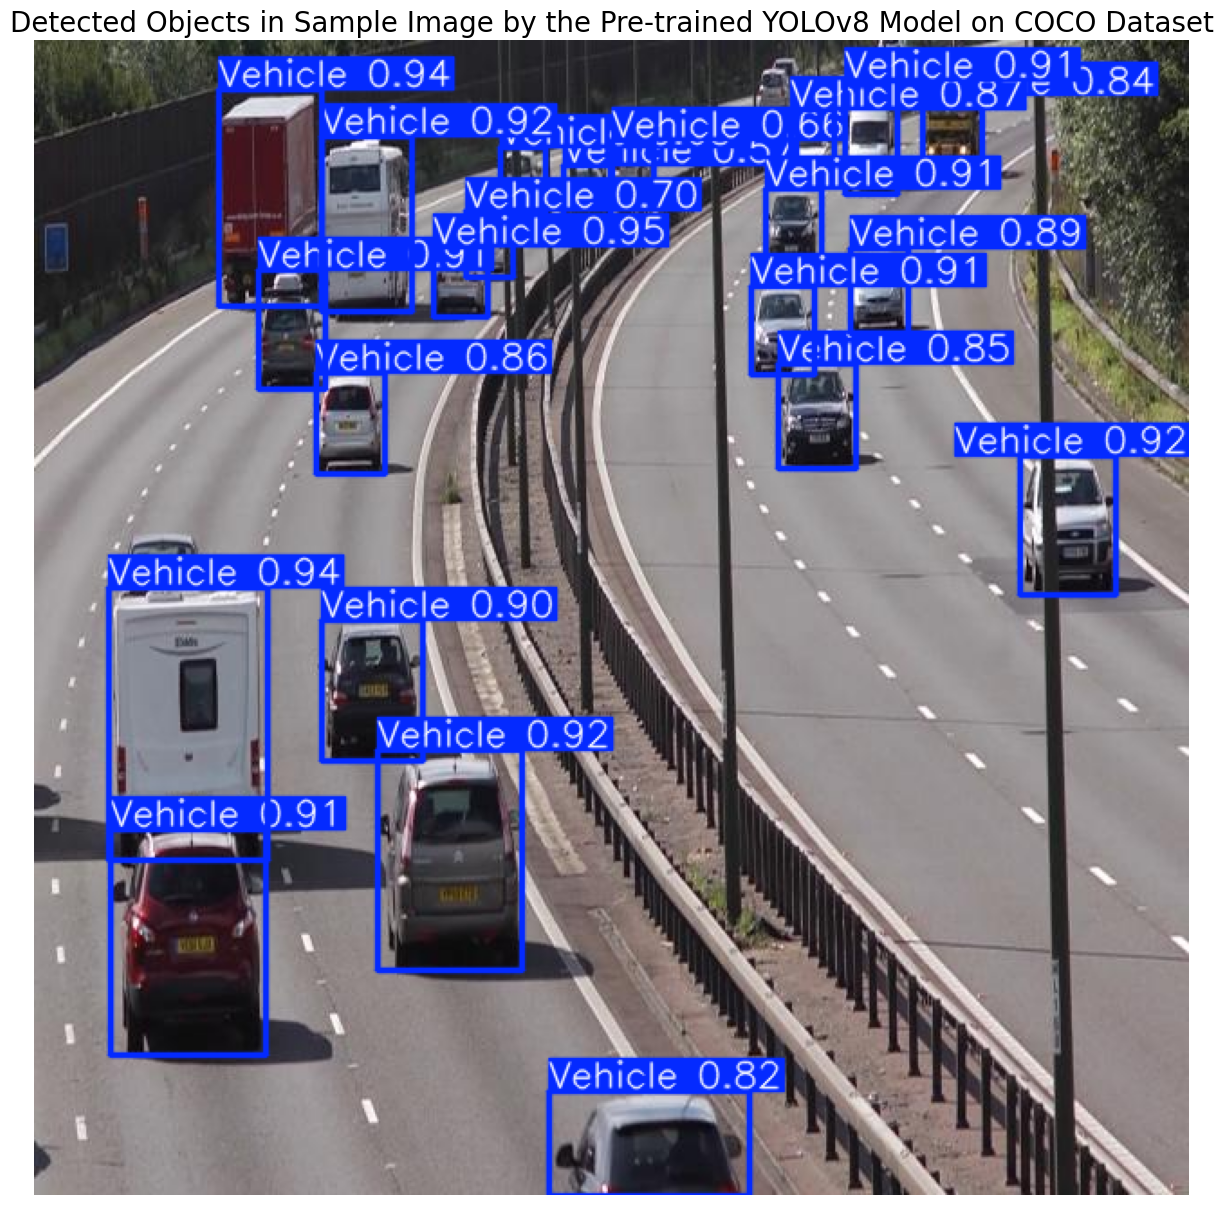

In [11]:
image_path = '/content/drive/MyDrive/Vehicle_Detection_Image_Dataset/train/images/10_mp4-10_jpg.rf.b87509668caff369c5501325477e6d9a.jpg'
import matplotlib.pyplot as plt
# Perform inference on the provided image(s)
results = vehicle_model.predict(source=image_path,
                        imgsz=640,  # Resize image to 640x640 (the size pf images the model was trained on)
                        conf=0.5)   # Confidence threshold: 50% (only detections above 50% confidence will be considered)

# Annotate and convert image to numpy array
sample_image = results[0].plot(line_width=2)

# Convert the color of the image from BGR to RGB for correct color representation in matplotlib
sample_image = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)

# Display annotated image
plt.figure(figsize=(20,15))
plt.imshow(sample_image)
plt.title('Detected Objects in Sample Image by the Pre-trained YOLOv8 Model on COCO Dataset', fontsize=20)
plt.axis('off')
plt.show()

# Detect Vehicle in video

In [13]:
import cv2
import os
from ultralytics import YOLO


# Input and output video file paths
input_video_path = '/content/challenge.mp4'  # Replace with your input video file path
output_video_path = '/content/car_challenge.avi'  # Path to save the output video

# Check if the input video file exists
if not os.path.exists(input_video_path):
    print(f"Error: The video file at {input_video_path} does not exist.")
    exit()

# Initialize video capture
cap = cv2.VideoCapture(input_video_path)

# Check if the video opened successfully
if not cap.isOpened():
    print("Error: Could not open video.")
    exit()

# Get video properties for output
fps = cap.get(cv2.CAP_PROP_FPS)  # Frames per second
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))  # Frame width
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))  # Frame height

# Initialize video writer to save output
fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Codec for mp4
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

# Process the video frame by frame
while True:
    ret, frame = cap.read()
    if not ret:
        break  # Exit if the frame is not captured correctly

    # Perform inference on the frame
    results = vehicle_model.predict(source=frame, imgsz=640, conf=0.5)

    # Annotate and convert frame to numpy array
    annotated_frame = results[0].plot(line_width=2)

    # Write the annotated frame to the output video
    out.write(annotated_frame)

    # Optional: Display the annotated frame (for testing purposes)
    # cv2.imshow('Detection in Video Frame', annotated_frame)

    # Optional: Add a short delay to visualize the video playback
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break  # Exit if 'q' is pressed

# Release resources
cap.release()
out.release()
cv2.destroyAllWindows()


0: 384x640 2 Vehicles, 35.7ms
Speed: 3.0ms preprocess, 35.7ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 Vehicles, 31.0ms
Speed: 5.3ms preprocess, 31.0ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 Vehicles, 15.4ms
Speed: 2.9ms preprocess, 15.4ms inference, 6.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 Vehicles, 10.7ms
Speed: 2.8ms preprocess, 10.7ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 Vehicles, 10.1ms
Speed: 3.7ms preprocess, 10.1ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 Vehicles, 12.6ms
Speed: 2.8ms preprocess, 12.6ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 Vehicles, 10.5ms
Speed: 2.6ms preprocess, 10.5ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 Vehicles, 12.1ms
Speed: 2.7ms preprocess, 12.1ms inference, 1.8ms postprocess per image at

# Merged Two model

In [14]:
import cv2
import numpy as np
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# Load your trained YOLO models
lane_model = YOLO('/content/lane.pt')  # Path to your lane segmentation model
vehicle_model = YOLO('/content/vehicle.pt')  # Path to your vehicle detection model

# Input and output video file paths
input_video_path = '/content/challenge.mp4'  # Replace with your input video file path
output_video_path = '/content/output_video_combined.mp4'  # Path to save the output video

# Initialize video capture
cap = cv2.VideoCapture(input_video_path)

# Get video properties
fps = cap.get(cv2.CAP_PROP_FPS)  # Frames per second
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))  # Frame width
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))  # Frame height

# Initialize video writer to save output
fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Codec for mp4
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

# Process the video
while True:
    ret, frame = cap.read()
    if not ret:
        break  # Exit if the frame is not captured correctly

    # Perform lane segmentation
    lane_results = lane_model(frame)  # Get segmentation results
    lane_mask = np.zeros((height, width), dtype=np.uint8)

    # Extract lane line masks
    for result in lane_results:
        if result.masks is not None:
            for mask_data in result.masks.data:
                mask_image = mask_data.cpu().numpy().astype(np.uint8)
                mask_image = cv2.resize(mask_image, (width, height))
                lane_mask = cv2.bitwise_or(lane_mask, mask_image)

    # Create a colored overlay for lane lines
    lane_overlay = np.zeros_like(frame)
    lane_overlay[:, :, 0] = 255  # Set the overlay color (e.g., blue)
    lane_overlay = cv2.bitwise_and(lane_overlay, lane_overlay, mask=lane_mask)

    # Blend the original frame with the lane overlay
    frame_with_lanes = cv2.addWeighted(frame, 1, lane_overlay, 0.5, 0)

    # Perform vehicle detection
    vehicle_results = vehicle_model.predict(source=frame, imgsz=640, conf=0.5)

    # Annotate vehicles on the frame
    for result in vehicle_results:
        for detection in result.boxes.data:
            class_id = int(detection[5])
            x1, y1, x2, y2 = map(int, detection[:4])
            cv2.rectangle(frame_with_lanes, (x1, y1), (x2, y2), (0, 255, 0), 2)  # Green box for vehicles

            # Optional: Add class label (if known)
            class_names = ['car']  # Replace with your class names
            class_name = class_names[class_id]  # Uncomment if you have class_names defined
            cv2.putText(frame_with_lanes, class_name, (x1, y1), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    # Write the processed frame to the output video
    out.write(frame_with_lanes)

    # Optional: Display the frame (for testing purposes)
    # cv2_imshow(frame_with_lanes)

# Release resources
cap.release()
out.release()
cv2.destroyAllWindows()


0: 384x640 4 LaneLines, 14.0ms
Speed: 2.1ms preprocess, 14.0ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 Vehicles, 6.7ms
Speed: 1.8ms preprocess, 6.7ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 LaneLines, 7.4ms
Speed: 1.7ms preprocess, 7.4ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 Vehicles, 9.4ms
Speed: 2.5ms preprocess, 9.4ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 LaneLines, 7.5ms
Speed: 2.9ms preprocess, 7.5ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 Vehicles, 6.7ms
Speed: 2.5ms preprocess, 6.7ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 LaneLines, 8.8ms
Speed: 2.5ms preprocess, 8.8ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 Vehicles, 14.1ms
Speed: 6.7ms preprocess, 14.1ms inference, 1.6ms postprocess per image at shape (

# Code with function that checks if a detected vehicle goes out of its lane

In [15]:
import cv2
import numpy as np
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# Load your trained YOLO models
lane_model = YOLO('/content/lane.pt')  # Path to your lane segmentation model
vehicle_model = YOLO('/content/vehicle.pt')  # Path to your vehicle detection model

# Input and output video file paths
input_video_path = '/content/challenge.mp4'  # Replace with your input video file path
output_video_path = '/content/output_video_combined_Alert.mp4'  # Path to save the output video

# Initialize video capture
cap = cv2.VideoCapture(input_video_path)

# Get video properties
fps = cap.get(cv2.CAP_PROP_FPS)  # Frames per second
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))  # Frame width
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))  # Frame height

# Initialize video writer to save output
fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Codec for mp4
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

def check_lane_position(vehicle_center_x, lane_boundaries):
    """Check if the vehicle is within lane boundaries."""
    left_boundary, right_boundary = lane_boundaries
    if vehicle_center_x < left_boundary or vehicle_center_x > right_boundary:
        return True  # Vehicle is out of lane
    return False  # Vehicle is within lane

# Process the video
while True:
    ret, frame = cap.read()
    if not ret:
        break  # Exit if the frame is not captured correctly

    # Perform lane segmentation
    lane_results = lane_model(frame)  # Get segmentation results
    lane_mask = np.zeros((height, width), dtype=np.uint8)

    # Extract lane line masks
    for result in lane_results:
        if result.masks is not None:
            for mask_data in result.masks.data:
                mask_image = mask_data.cpu().numpy().astype(np.uint8)
                mask_image = cv2.resize(mask_image, (width, height))
                lane_mask = cv2.bitwise_or(lane_mask, mask_image)

    # Create a colored overlay for lane lines
    lane_overlay = np.zeros_like(frame)
    lane_overlay[:, :, 0] = 255  # Set the overlay color (e.g., blue)
    lane_overlay = cv2.bitwise_and(lane_overlay, lane_overlay, mask=lane_mask)

    # Blend the original frame with the lane overlay
    frame_with_lanes = cv2.addWeighted(frame, 1, lane_overlay, 0.5, 0)

    # Perform vehicle detection
    vehicle_results = vehicle_model.predict(source=frame, imgsz=640, conf=0.5)

    # Annotate vehicles on the frame
    for result in vehicle_results:
        for detection in result.boxes.data:
            class_id = int(detection[5])
            x1, y1, x2, y2 = map(int, detection[:4])
            vehicle_center_x = (x1 + x2) // 2  # Calculate vehicle center position

            # Check if the vehicle is out of the lane
            lane_boundaries = (width * 0.3, width * 0.7)  # Example lane boundaries (adjust as needed)
            if check_lane_position(vehicle_center_x, lane_boundaries):
                cv2.putText(frame_with_lanes, "Out of Lane!", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

            cv2.rectangle(frame_with_lanes, (x1, y1), (x2, y2), (0, 255, 0), 2)  # Green box for vehicles

            # Optional: Add class label (if known)
            class_names = ['car']  # Replace with your class names
            class_name = class_names[class_id]  # Uncomment if you have class_names defined
            cv2.putText(frame_with_lanes, class_name, (x1, y1), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    # Write the processed frame to the output video
    out.write(frame_with_lanes)

    # Optional: Display the frame (for testing purposes)
    cv2_imshow(frame_with_lanes)

# Release resources
cap.release()
out.release()
cv2.destroyAllWindows()

Output hidden; open in https://colab.research.google.com to view.

# measure the distance

In [24]:
from google.colab.patches import cv2_imshow  # Import cv2_imshow for Colab
import cv2
import numpy as np
import torch

# Load the YOLOv5 model
model = torch.hub.load('ultralytics/yolov5', 'yolov5s')

# Constants for known width and focal length
KNOWN_WIDTH = 1.8  # Average width of a vehicle in meters
FOCAL_LENGTH = 700  # Focal length in pixels (calibrated for your camera)

def calculate_distance(center1, center2):
    """Calculate the Euclidean distance between two points."""
    return np.linalg.norm(np.array(center1) - np.array(center2))

def calculate_real_world_coordinates(box):
    """Convert bounding box to real-world coordinates."""
    x1, y1, x2, y2 = box
    center_x = (x1 + x2) / 2
    center_y = (y1 + y2) / 2
    width_in_frame = x2 - x1
    distance = (KNOWN_WIDTH * FOCAL_LENGTH) / width_in_frame
    return (center_x, center_y, distance)

# Load video
input_video_path = '/content/output_video_combined_Alert.mp4'  # Path to your input video
output_video_path = 'output_video_final.mp4'  # Path for saving output video
cap = cv2.VideoCapture(input_video_path)

# Get video properties
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Change codec to 'mp4v' for MP4
output_video = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Perform vehicle detection
    results = model(frame)  # Pass the frame to the model
    detections = results.xyxy[0]  # Get detections (x1, y1, x2, y2, confidence, class)

    vehicle_centers = []

    for *box, conf, cls in detections:
        if int(cls) == 2:  # Class index for cars (adjust if necessary)
            box = list(map(int, box))  # Convert to integers
            center_x, center_y, distance = calculate_real_world_coordinates(box)
            vehicle_centers.append((center_x, center_y, distance))

            # Draw bounding box and label
            cv2.rectangle(frame, (box[0], box[1]), (box[2], box[3]), (255, 0, 0), 2)
            cv2.putText(frame, f'Distance: {distance:.2f}m', (box[0], box[1] - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    # Display the resulting frame
    cv2_imshow(frame)  # Use cv2_imshow instead of cv2.imshow

    # Write the processed frame to the output video
    output_video.write(frame)

# Release resources
cap.release()
output_video.release()

# Optional: convert video format using ffmpeg if needed
!ffmpeg -i output_video.mp4 -codec:v libx264 -preset fast -crf 22 output_video_converted.mp4

Output hidden; open in https://colab.research.google.com to view.

In [26]:
from google.colab import files

# Download the resulting video file
files.download('/content/output_video_final.mp4')  # Change the filename if necessary

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>